# 🤖 Machine Learning — PP1: Clusterização de Municípios Brasileiros
> **Projeto Brasil em Foco — PISI3 — UFRPE 2026.1**
>
> 👥 **Autores**: Arthur Barbosa, Danielly Nunes, Gabriel Sabino, Isadora Morais, Luiz Vinícius

---

## 🎯 Objetivo

Este notebook implementa a **Pergunta de Pesquisa 1 (PP1)**:

> *Como técnicas de aprendizado não supervisionado podem ser utilizadas para identificar padrões e agrupar cidades brasileiras com potencial turístico semelhante?*

Seguindo a metodologia **KDD (Knowledge Discovery in Databases)**, aplicamos algoritmos de clusterização para segmentar os municípios brasileiros em grupos com perfis turísticos similares, identificando padrões ocultos — incluindo as chamadas **Joias Escondidas**: cidades com alta qualidade de vida e baixa infraestrutura turística.

---

## 📋 Etapas do KDD neste notebook

| Fase | Descrição |
|------|-----------|
| **Fase 1** | Seleção e preparação das features |
| **Fase 2** | Pré-processamento (normalização, tratamento de outliers) |
| **Fase 3** | Mineração — Aplicação dos algoritmos de clusterização |
| **Fase 4** | Avaliação — Cotovelo, Silhueta e comparação entre algoritmos |
| **Fase 5** | Interpretação dos clusters e identificação das Joias Escondidas |

---
## 📦 Importação das Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn — pré-processamento
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA

# Sklearn — algoritmos de clusterização
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Sklearn — métricas de avaliação
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score

# Configurações visuais
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 6)

SEED = 42
print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


---
## 📥 Carregamento dos Dados

In [ ]:
# ⚠️ Ajuste o caminho conforme seu ambiente (Colab, local, etc.)
# No Colab:
# from google.colab import drive
# drive.mount('/content/drive')
# df_raw = pd.read_csv('/content/drive/MyDrive/brazilian_cities/BRAZIL_CITIES.csv', sep=';', encoding='latin-1')

df_raw = pd.read_csv('BRAZIL_CITIES.csv', sep=';', encoding='latin-1')

# Padronização dos nomes de colunas (mesma lógica da EDA)
df_raw.columns = (
    df_raw.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_', regex=False)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)

print(f'✅ Dataset carregado: {df_raw.shape[0]} municípios | {df_raw.shape[1]} variáveis')
df_raw.head(3)

✅ Dataset carregado: 5573 municípios | 81 variáveis


,city,state,capital,ibge_res_pop,ibge_res_pop_bras,ibge_res_pop_estr,ibge_du,ibge_du_urban,ibge_du_rural,ibge_pop,...,pu_bank,pr_assets,pu_assets,cars,motorcycles,wheeled_tractor,uber,mac,walmart,post_offices
0,Abadia De GoiÃ¡s,GO,0,6876.0,6876.0,0.0,2137.0,1546.0,591.0,5300.0,...,NaN,NaN,NaN,2158.0,1246.0,0.0,NaN,NaN,NaN,1.0
1,Abadia Dos Dourados,MG,0,6704.0,6704.0,0.0,2328.0,1481.0,847.0,4154.0,...,NaN,NaN,NaN,2227.0,1142.0,0.0,NaN,NaN,NaN,1.0
2,AbadiÃ¢nia,GO,0,15757.0,15609.0,148.0,4655.0,3233.0,1422.0,10656.0,...,1.0,33724584.0,67091904.0,2838.0,1426.0,0.0,NaN,NaN,NaN,3.0


---
## 🔧 Fase 1 — Seleção e Engenharia de Features

### Critérios de seleção

Seguindo a metodologia KDD, selecionamos variáveis que representem as **três dimensões do perfil turístico** identificadas na EDA, mais o porte urbano:

| Dimensão (Dashboard) | Variáveis da Clusterização | Variáveis correspondentes no Dashboard |
|---|---|---|
| **Potencial Turístico** | `idhm`, `gdp_capita` | `idhm`, `indice_potencial_turistico_proxy` |
| **Conversão Turística** | `leitos_1000hab`, `hoteis_1000hab` | `indice_oferta_hoteleira_observada`, `indice_conversao_turistica_proxy` |
| **Infraestrutura e Conveniência** | `servicos_1000hab`, `agencias_total`, `uber` | `indice_infraestrutura`, `indice_modernizacao` |
| **Porte Urbano** | `estimated_pop` | — (usado apenas como contexto) |

> **Pontos 1 e 2 — consistência com a EDA:** Todas as variáveis "por habitante" usam `ibge_res_pop` como denominador e a escala "por 1.000 habitantes" — exatamente como na EDA. `estimated_pop` permanece como variável independente para capturar o porte urbano, sem interferir nas razões.

> **Ponto 3 — índices do Dashboard:** Os índices `indice_infraestrutura`, `indice_potencial_turistico_proxy`, `indice_conversao_turistica_proxy`, `potencial_joia_escondida` e `quadrante_dashboard` são calculados com a MESMA fórmula do Dashboard e da EDA. Eles **não entram como features do K-Means** (evita redundância com as variáveis acima), mas são usados para: (1) nomear os clusters de forma interpretável (Fase 5.1) e (2) identificar as Joias Escondidas com o mesmo critério do app (Fase 5.2).

> **Atributos categóricos:** `city`, `state` e `macrorregiao` não entram no K-Means (que trabalha com distância numérica). São mantidos apenas para interpretação dos clusters. Se forem usados na etapa de Classificação (PP2), devem passar por One-Hot Encoding.

In [ ]:
df = df_raw.copy()

# ── Mapeamento estado → macrorregião (mesmo dicionário da EDA) ────────────
map_regiao = {
    'AC':'Norte','AM':'Norte','AP':'Norte','PA':'Norte','RO':'Norte','RR':'Norte','TO':'Norte',
    'AL':'Nordeste','BA':'Nordeste','CE':'Nordeste','MA':'Nordeste','PB':'Nordeste',
    'PE':'Nordeste','PI':'Nordeste','RN':'Nordeste','SE':'Nordeste',
    'DF':'Centro-Oeste','GO':'Centro-Oeste','MS':'Centro-Oeste','MT':'Centro-Oeste',
    'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
    'PR':'Sul','RS':'Sul','SC':'Sul',
}
df['macrorregiao'] = df['state'].map(map_regiao)

# ── Conversões numéricas ───────────────────────────────────────────────────
for col in ['estimated_pop','ibge_res_pop','hotels','beds','comp_i',
            'pr_agencies','pu_agencies','uber','gdp_capita','idhm',
            'pay_tv','fixed_phones','comp_j','comp_g',
            'gva_agropec','gva_industry','gva_services','gva_public','gva_total']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['hotels','beds','comp_i','uber','pr_agencies','pu_agencies',
            'pay_tv','fixed_phones','comp_j','comp_g',
            'gva_agropec','gva_industry','gva_services','gva_public','gva_total']:
    df[col] = df[col].fillna(0)

# ── PONTOS 1 e 2: mesmo denominador (ibge_res_pop) e mesma escala (/1.000 hab.) da EDA ──
pop_ref = df['ibge_res_pop'].replace(0, np.nan) + 1

df['leitos_1000hab']   = (df['beds']   / pop_ref) * 1000
df['hoteis_1000hab']   = (df['hotels'] / pop_ref) * 1000   # antes: hoteis_por_hab (escala diferente)
df['servicos_1000hab'] = (df['comp_i'] / pop_ref) * 1000   # antes: servicos_por_hab (escala diferente)
df['agencias_total']   = df['pr_agencies'] + df['pu_agencies']

# ── PONTO 3: índices compostos do Dashboard (mesma fórmula da EDA) ─────────
def _positive_percentile_score(series):
    values = pd.to_numeric(series, errors='coerce').fillna(0)
    score = pd.Series(0.0, index=values.index)
    positive = values > 0
    score.loc[positive] = values.loc[positive].rank(pct=True, method='average') * 100
    return score

def _norm_max(s):
    m = s.max()
    return (s / m).clip(upper=1) if m > 0 else s * 0

hoteis_score = _positive_percentile_score(df['hotels'])
leitos_score = _positive_percentile_score(df['beds'])
df['indice_oferta_hoteleira_observada'] = (leitos_score * 0.65 + hoteis_score * 0.35).round(1)

df['indice_infraestrutura'] = (
    _norm_max(df['hotels'])         * 0.25 +
    _norm_max(df['beds'])           * 0.25 +
    _norm_max(df['agencias_total']) * 0.20 +
    (df['uber'] > 0).astype(int)    * 0.15 +
    _norm_max(df['comp_g'])         * 0.15
).fillna(0).mul(100).round(1)

df['indice_modernizacao'] = (
    (df['uber'] > 0).astype(int)  * 0.25 +
    _norm_max(df['pay_tv'])         * 0.20 +
    _norm_max(df['fixed_phones'])   * 0.20 +
    _norm_max(df['comp_j'])         * 0.20 +
    _norm_max(df['comp_g'])         * 0.15
).fillna(0).mul(100).round(1)

def _diversidade(row):
    total = row['gva_total']
    if total == 0:
        return 0.0
    props = [row['gva_agropec']/total, row['gva_industry']/total,
             row['gva_services']/total, row['gva_public']/total]
    entropy = -sum(p * np.log(p) if p > 0 else 0 for p in props)
    return max(0, min(100, (entropy / np.log(4)) * 100))

df['indice_diversidade_economica'] = df.apply(_diversidade, axis=1).round(1)

categoria_score = (
    df.get('categoria_tur', pd.Series('', index=df.index)).astype(str).str.strip()
    .map({'A':100,'B':80,'C':60,'D':40,'E':20})
    .fillna(0)
)

df['indice_potencial_turistico_proxy'] = (
    df['idhm'].clip(lower=0, upper=1) * 100 * 0.35
    + df['indice_modernizacao'] * 0.25
    + df['indice_diversidade_economica'] * 0.15
    + categoria_score * 0.25
).clip(lower=0, upper=100).round(1)

df['indice_conversao_turistica_proxy'] = (
    df['indice_oferta_hoteleira_observada'] * 0.45
    + df['indice_infraestrutura'] * 0.55
).clip(lower=0, upper=100).round(1)

df['potencial_joia_escondida'] = (
    df['indice_potencial_turistico_proxy'] - df['indice_conversao_turistica_proxy']
).clip(lower=0, upper=100).round(1)

idhm_p70   = df['idhm'].quantile(0.70)
oferta_p90 = df['indice_oferta_hoteleira_observada'].quantile(0.90)

df['quadrante_dashboard'] = 'Outros'
df.loc[(df['idhm'] >= idhm_p70) & (df['indice_oferta_hoteleira_observada'] <= oferta_p90), 'quadrante_dashboard'] = 'Alto IDH + Estrutura Limitada'
df.loc[(df['idhm'] >= idhm_p70) & (df['indice_oferta_hoteleira_observada'] >  oferta_p90), 'quadrante_dashboard'] = 'Alto IDH + Alta Oferta Hoteleira'
df.loc[(df['idhm'] <  idhm_p70) & (df['indice_oferta_hoteleira_observada'] >  oferta_p90), 'quadrante_dashboard'] = 'Alta Oferta + Baixo IDH'

# ── Seleção das features para clusterização ────────────────────────────────
FEATURES = [
    'gdp_capita',
    'idhm',
    'leitos_1000hab',
    'hoteis_1000hab',
    'servicos_1000hab',
    'agencias_total',
    'uber',
    'estimated_pop'
]

COLS_EXTRA = ['potencial_joia_escondida', 'quadrante_dashboard',
              'indice_infraestrutura', 'indice_potencial_turistico_proxy',
              'indice_conversao_turistica_proxy']

df_ml = df[['city', 'state', 'macrorregiao'] + FEATURES + COLS_EXTRA].dropna(
    subset=['gdp_capita', 'idhm', 'estimated_pop']
)
df_ml = df_ml.fillna(0)

print(f'✅ Dataset para ML: {df_ml.shape[0]} municípios | {len(FEATURES)} features de clusterização')
print(f'   Municípios removidos por nulos: {df_raw.shape[0] - df_ml.shape[0]}')
print(f'\n   Variáveis extras (não entram no KMeans, só interpretação):')
for c in COLS_EXTRA:
    print(f'     • {c}')
df_ml[FEATURES].describe().round(2)

✅ Dataset para ML: 5564 municípios | 8 features de clusterização
   Municípios removidos por nulos: 9

   Variáveis extras (não entram no KMeans, só interpretação):
     • potencial_joia_escondida
     • quadrante_dashboard
     • indice_infraestrutura
     • indice_potencial_turistico_proxy
     • indice_conversao_turistica_proxy


,gdp_capita,idhm,leitos_1000hab,hoteis_1000hab,servicos_1000hab,agencias_total,uber,estimated_pop
count,5564.00,5564.00,5564.00,5564.00,5564.00,5564.00,5564.00,5564.00
mean,21121.63,0.66,1.11,0.02,1.11,3.73,0.02,37461.82
std,20318.92,0.07,11.83,0.15,1.49,37.34,0.15,220085.64
min,3190.57,0.42,0.00,0.00,0.00,0.00,0.00,786.00
25%,9061.89,0.60,0.00,0.00,0.21,0.00,0.00,5453.00
50%,15869.62,0.66,0.00,0.00,0.73,1.00,0.00,11591.00
75%,26155.41,0.72,0.00,0.00,1.63,3.00,0.00,25306.50
max,314637.69,0.86,710.53,5.10,47.13,2319.00,1.00,12176866.00


---
## 🔧 Fase 2 — Pré-processamento

### 2.1 Tratamento de Outliers

Variáveis como `gdp_capita` e `leitos_1000hab` possuem outliers extremos (identificados na EDA — ex: Paulínia com PIB de R$314k). Aplicamos **Winsorização** no percentil 99 para limitar a influência desses valores sem removê-los.

✅ Winsorização aplicada (p1–p99) nas variáveis com outliers extremos
Fonte: elaborado pelos autores (2026).


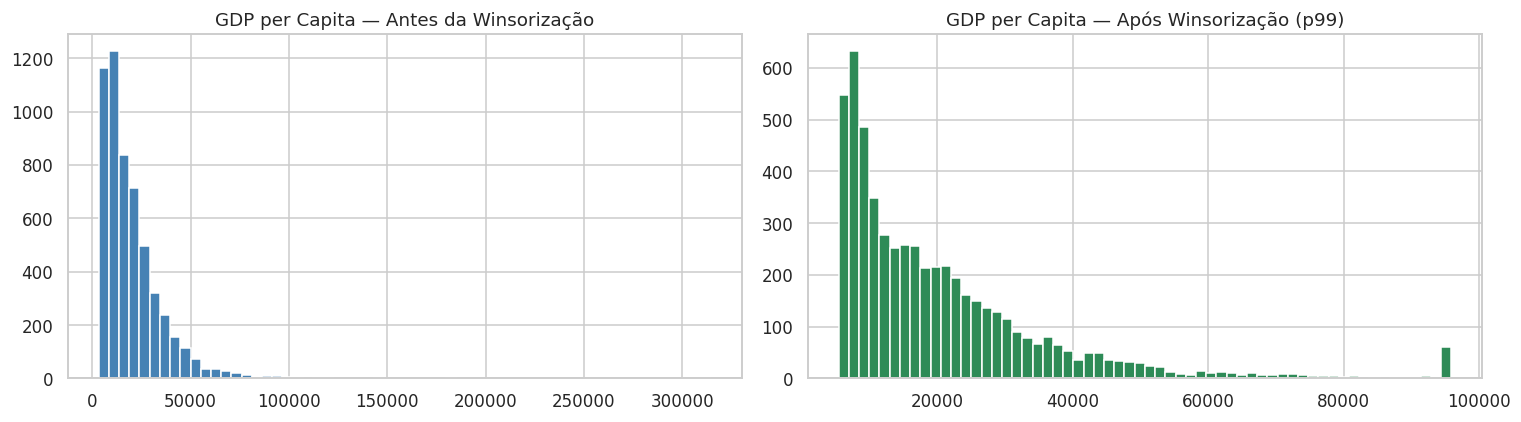

In [ ]:
from scipy.stats import mstats

df_proc = df_ml.copy()

# Winsorização no percentil 1-99 para variáveis com outliers extremos
COLS_WINSORIZE = ['gdp_capita', 'leitos_1000hab', 'hoteis_1000hab',
                  'servicos_1000hab', 'agencias_total', 'estimated_pop']

for col in COLS_WINSORIZE:
    p01 = df_proc[col].quantile(0.01)
    p99 = df_proc[col].quantile(0.99)
    df_proc[col] = df_proc[col].clip(lower=p01, upper=p99)

print('✅ Winsorização aplicada (p1–p99) nas variáveis com outliers extremos')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_ml['gdp_capita'].hist(bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('GDP per Capita — Antes da Winsorização')
df_proc['gdp_capita'].hist(bins=60, ax=axes[1], color='seagreen')
axes[1].set_title('GDP per Capita — Após Winsorização (p99)')
plt.tight_layout()
plt.savefig('fig_winsorization.png', dpi=110, bbox_inches='tight')
print('Fonte: elaborado pelos autores (2026).')
plt.show()

### 2.2 Normalização

Algoritmos baseados em distância (K-Means, Hierárquico) são sensíveis à escala das variáveis. Utilizamos **RobustScaler** — mais resistente a outliers residuais que o StandardScaler — para padronizar todas as features.

In [ ]:
X = df_proc[FEATURES].values

# RobustScaler: usa mediana e IQR — mais robusto a outliers que StandardScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print('✅ Normalização aplicada com RobustScaler')
print(f'   Shape do array normalizado: {X_scaled.shape}')

# Verificação: média próxima de 0, desvio próximo de 1
df_scaled_check = pd.DataFrame(X_scaled, columns=FEATURES)
print('\nEstatísticas após normalização:')
df_scaled_check.describe().round(3)

✅ Normalização aplicada com RobustScaler
   Shape do array normalizado: (5564, 8)

Estatísticas após normalização:


,gdp_capita,idhm,leitos_1000hab,hoteis_1000hab,servicos_1000hab,agencias_total,uber,estimated_pop
count,5564.000,5564.000,5564.000,5564.000,5564.000,5564.000,5564.000,5564.000
mean,0.273,-0.049,0.700,0.014,0.237,0.479,0.022,0.885
std,0.938,0.605,2.510,0.049,0.767,1.700,0.148,2.976
min,-0.610,-2.076,0.000,0.000,-0.512,-0.333,0.000,-0.499
25%,-0.398,-0.555,0.000,0.000,-0.362,-0.333,0.000,-0.309
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.602,0.445,0.000,0.000,0.638,0.667,0.000,0.691
max,4.681,1.655,17.718,0.338,3.360,12.333,1.000,20.494


### 2.3 Redução de Dimensionalidade com PCA

Aplicamos PCA para visualização 2D dos clusters. O PCA não substitui as features originais na clusterização — é usado apenas para visualização.

✅ PCA aplicado para visualização 2D
   Variância explicada: PC1=58.5% | PC2=31.7% | Total=90.2%


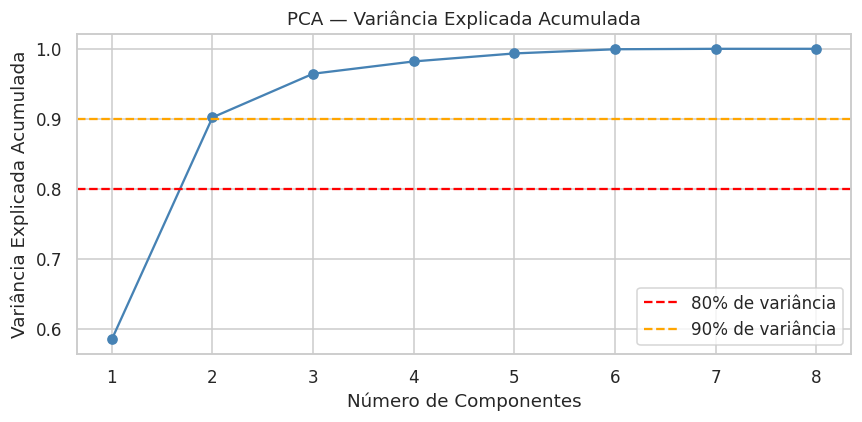

Fonte: elaborado pelos autores (2026).


In [ ]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_
print(f'✅ PCA aplicado para visualização 2D')
print(f'   Variância explicada: PC1={var_exp[0]:.1%} | PC2={var_exp[1]:.1%} | Total={sum(var_exp):.1%}')

# Gráfico de variância explicada acumulada
pca_full = PCA(random_state=SEED).fit(X_scaled)
var_cum = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(var_cum)+1), var_cum, marker='o', color='steelblue')
plt.axhline(0.80, color='red', linestyle='--', label='80% de variância')
plt.axhline(0.90, color='orange', linestyle='--', label='90% de variância')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.title('PCA — Variância Explicada Acumulada')
plt.legend()
plt.tight_layout()
plt.savefig('fig_pca_variance.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

---
## ⛏️ Fase 3 — Mineração: Aplicação dos Algoritmos

### 3.1 Método do Cotovelo (Elbow Method) — K-Means

O método do cotovelo analisa a **inércia** (soma das distâncias quadráticas de cada ponto ao centroide do seu cluster) para diferentes valores de K. O ponto onde a redução de inércia desacelera significativamente — formando um "cotovelo" — indica o K ideal.

In [ ]:
K_RANGE = range(2, 11)
inertias = []
silhouettes = []

print('⏳ Calculando inércia e silhueta para K=2 até K=10...')

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20, max_iter=500)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f'   K={k} | Inércia: {km.inertia_:,.0f} | Silhueta: {silhouette_score(X_scaled, labels):.4f}')

print('\n✅ Cálculo concluído!')

⏳ Calculando inércia e silhueta para K=2 até K=10...
   K=2 | Inércia: 62,565 | Silhueta: 0.8060
   K=3 | Inércia: 35,604 | Silhueta: 0.7774
   K=4 | Inércia: 26,824 | Silhueta: 0.5969
   K=5 | Inércia: 21,535 | Silhueta: 0.6139
   K=6 | Inércia: 17,635 | Silhueta: 0.3637
   K=7 | Inércia: 15,080 | Silhueta: 0.3658
   K=8 | Inércia: 13,634 | Silhueta: 0.3657
   K=9 | Inércia: 12,333 | Silhueta: 0.3463
   K=10 | Inércia: 11,182 | Silhueta: 0.3489

✅ Cálculo concluído!


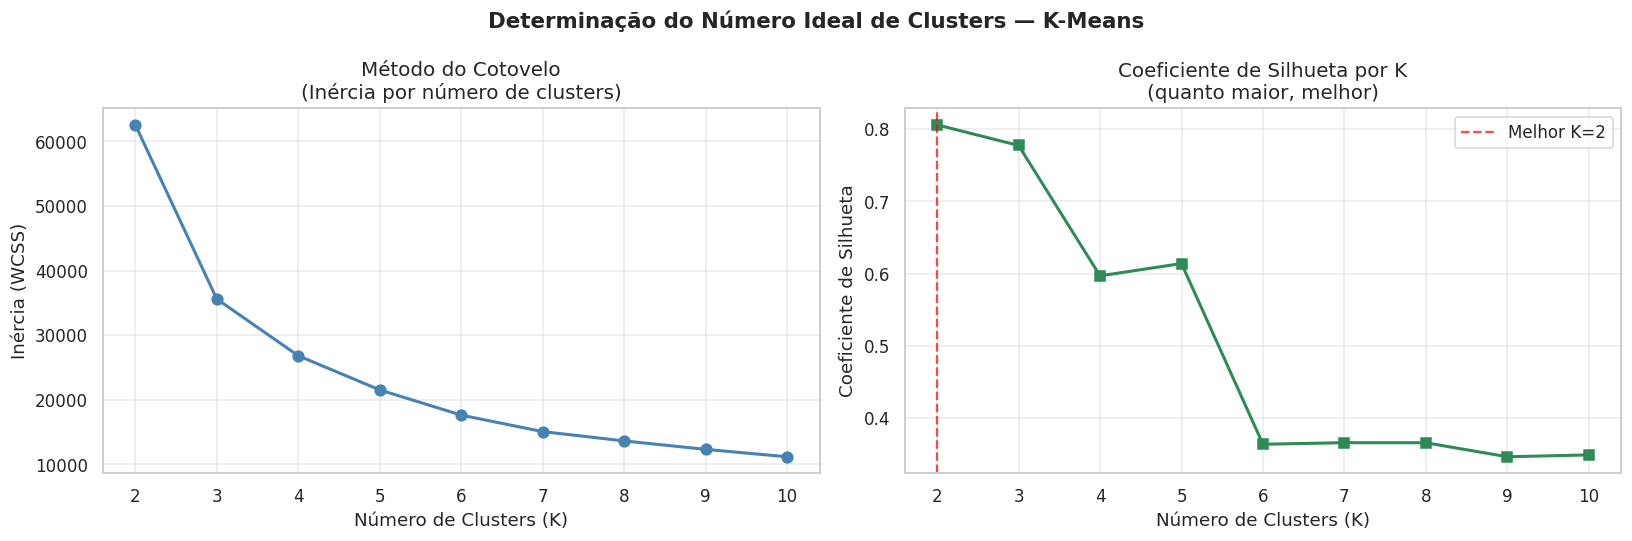

📌 Melhor K pelo coeficiente de silhueta: K=2
Fonte: elaborado pelos autores (2026).


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Cotovelo ──────────────────────────────────────────────────────────────
axes[0].plot(list(K_RANGE), inertias, marker='o', color='steelblue', linewidth=2, markersize=7)
axes[0].set_title('Método do Cotovelo\n(Inércia por número de clusters)', fontsize=13)
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inércia (WCSS)')
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[0].grid(True, alpha=0.4)

# ── Silhueta ──────────────────────────────────────────────────────────────
axes[1].plot(list(K_RANGE), silhouettes, marker='s', color='seagreen', linewidth=2, markersize=7)
axes[1].set_title('Coeficiente de Silhueta por K\n(quanto maior, melhor)', fontsize=13)
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Coeficiente de Silhueta')
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1].grid(True, alpha=0.4)

# Destacar melhor K
best_k_silhouette = list(K_RANGE)[np.argmax(silhouettes)]
axes[1].axvline(best_k_silhouette, color='red', linestyle='--', alpha=0.7,
                label=f'Melhor K={best_k_silhouette}')
axes[1].legend()

plt.suptitle('Determinação do Número Ideal de Clusters — K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cotovelo_silhueta.png', dpi=110, bbox_inches='tight')
plt.show()
print(f'📌 Melhor K pelo coeficiente de silhueta: K={best_k_silhouette}')
print('Fonte: elaborado pelos autores (2026).')

### 3.2 Gráfico de Silhueta Detalhado

O gráfico de silhueta mostra o coeficiente individual de cada ponto em cada cluster. Valores próximos de 1 indicam que o ponto está bem posicionado no seu cluster; valores negativos indicam possível classificação errada.

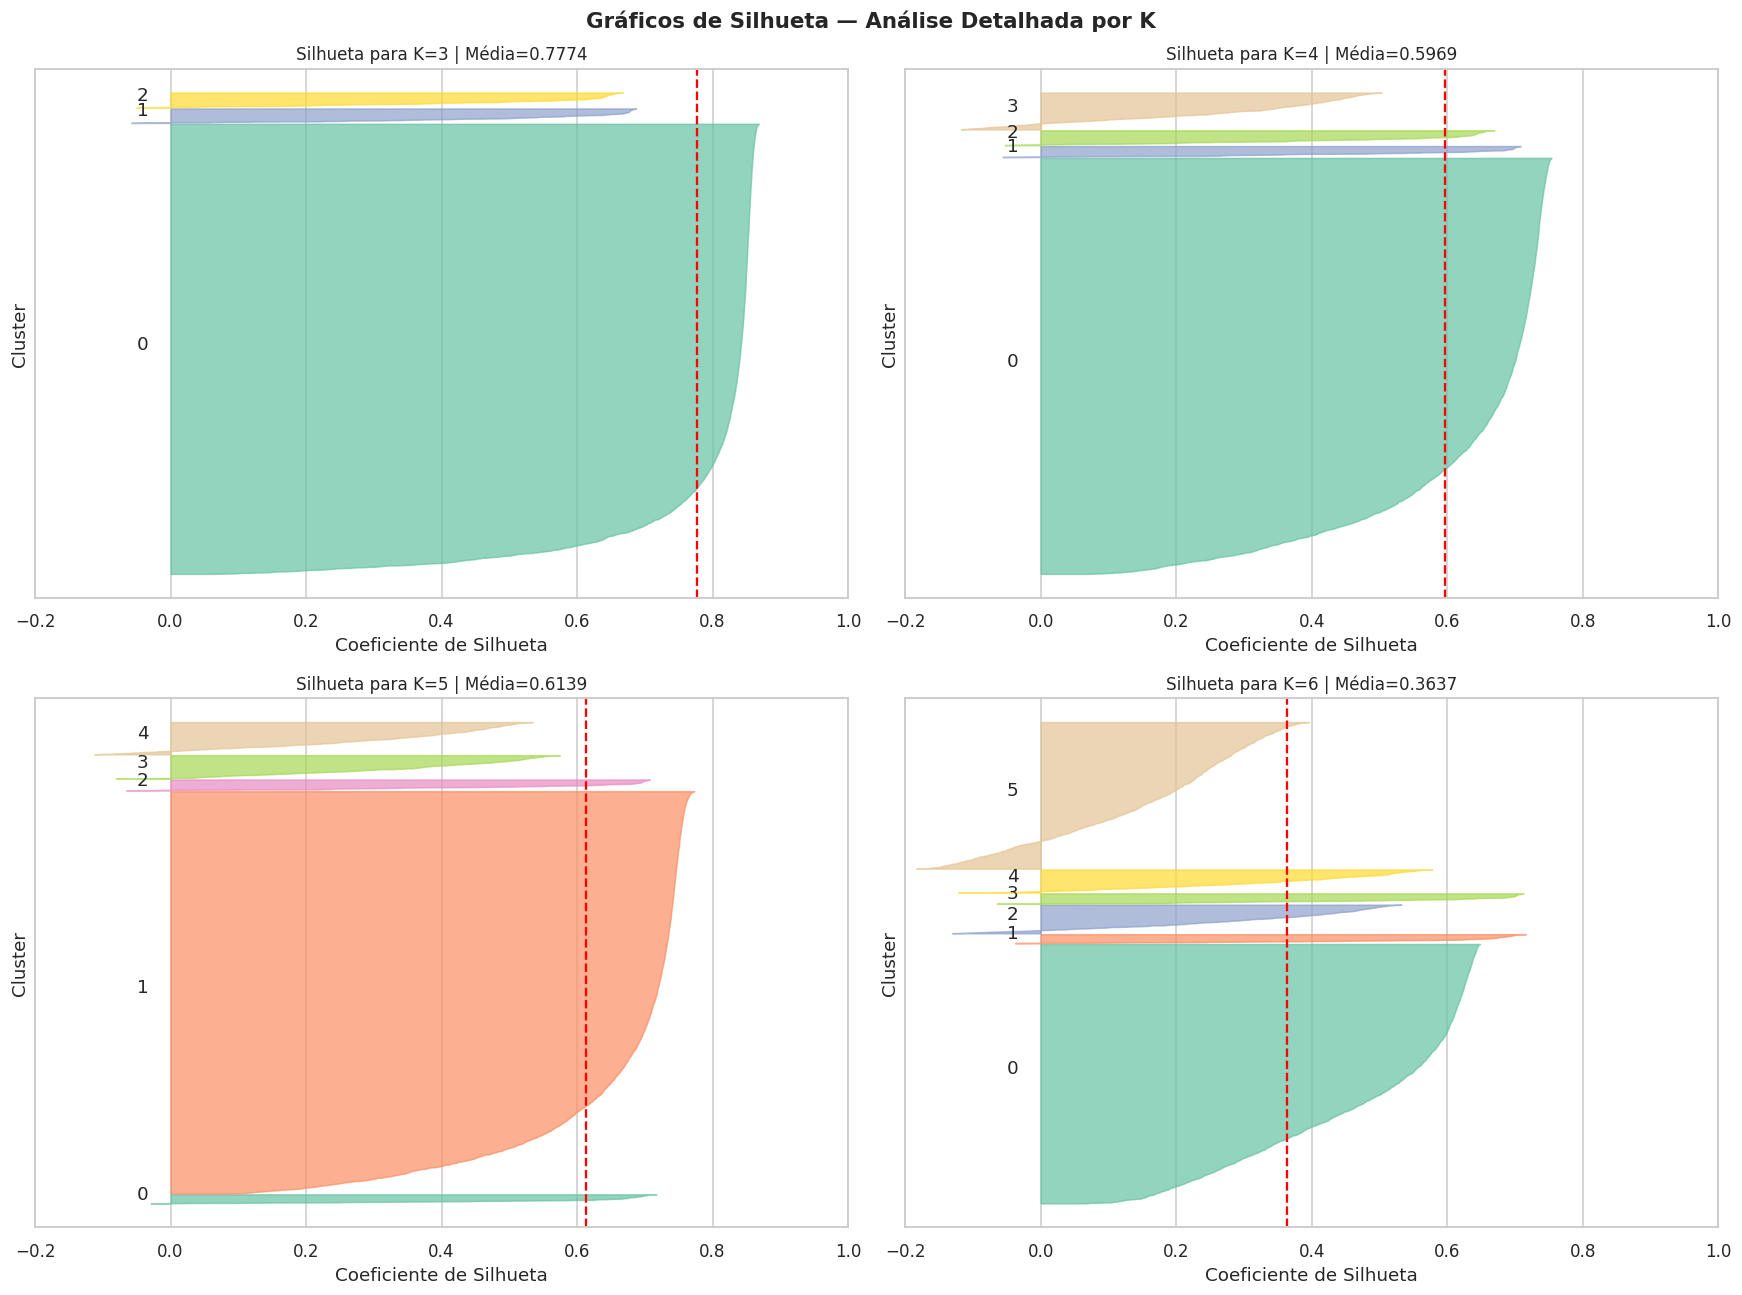

Fonte: elaborado pelos autores (2026).


In [ ]:
from matplotlib.cm import get_cmap

K_PLOT = [3, 4, 5, 6]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, k in enumerate(K_PLOT):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil_avg = silhouette_score(X_scaled, labels)
    sil_vals = silhouette_samples(X_scaled, labels)

    ax = axes[idx]
    y_lower = 10
    cmap = get_cmap('Set2')

    for i in range(k):
        sil_i = np.sort(sil_vals[labels == i])
        size_i = sil_i.shape[0]
        y_upper = y_lower + size_i
        color = cmap(i / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_i,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
        y_lower = y_upper + 10

    ax.axvline(sil_avg, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f'Silhueta para K={k} | Média={sil_avg:.4f}', fontsize=11)
    ax.set_xlabel('Coeficiente de Silhueta')
    ax.set_ylabel('Cluster')
    ax.set_yticks([])
    ax.set_xlim([-0.2, 1])

plt.suptitle('Gráficos de Silhueta — Análise Detalhada por K', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_silhueta_detalhada.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

### 3.3 Comparação entre Algoritmos

Além do K-Means, testamos **Clusterização Hierárquica Aglomerativa** e **DBSCAN** para verificar se os padrões encontrados são robustos independentemente do algoritmo.

| Algoritmo | Tipo | Vantagem | Limitação |
|-----------|------|----------|-----------|
| **K-Means** | Particionamento | Rápido, escalável | Assume clusters esféricos, sensível a outliers |
| **Hierárquico** | Aglomerativo | Não precisa definir K a priori, produz dendrograma | Alto custo computacional |
| **DBSCAN** | Densidade | Detecta outliers, clusters de forma arbitrária | Sensível aos parâmetros eps e min_samples |

In [ ]:
# ── Definir K final ─────────────────────────────────────────────────────
# A silhueta apontou um K menor como melhor valor numérico (best_k_silhouette),
# mas K=4 foi escolhido por oferecer melhor capacidade interpretativa para o
# problema turístico, permitindo diferenciar: destinos já convertidos em
# estrutura turística, municípios com baixa estrutura, polos urbanos
# consolidados e municípios com potencial não convertido. O método do
# cotovelo indica redução relevante da inércia até aproximadamente K=4,
# e essa escolha permite diferenciar perfis mais úteis para a análise do dashboard.
K_FINAL = 4

print(f'📊 Melhor K pela silhueta: K={best_k_silhouette}')
print(f'🎯 K escolhido para a análise: K={K_FINAL} (ver justificativa acima)')
print('='*60)

resultados = {}

# ── 1. K-Means ───────────────────────────────────────────────────────────
km_final = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=20, max_iter=500)
labels_km = km_final.fit_predict(X_scaled)
resultados['K-Means'] = labels_km

sil_km = silhouette_score(X_scaled, labels_km)
db_km  = davies_bouldin_score(X_scaled, labels_km)
ch_km  = calinski_harabasz_score(X_scaled, labels_km)
print(f'\n📊 K-Means (K={K_FINAL})')
print(f'   Silhueta:           {sil_km:.4f}  (↑ quanto maior, melhor)')
print(f'   Davies-Bouldin:     {db_km:.4f}  (↓ quanto menor, melhor)')
print(f'   Calinski-Harabasz:  {ch_km:.1f}  (↑ quanto maior, melhor)')

# ── 2. Clusterização Hierárquica ────────────────────────────────────────
agg = AgglomerativeClustering(n_clusters=K_FINAL, linkage='ward')
labels_agg = agg.fit_predict(X_scaled)
resultados['Hierárquico'] = labels_agg

sil_agg = silhouette_score(X_scaled, labels_agg)
db_agg  = davies_bouldin_score(X_scaled, labels_agg)
ch_agg  = calinski_harabasz_score(X_scaled, labels_agg)
print(f'\n📊 Clusterização Hierárquica (Ward, K={K_FINAL})')
print(f'   Silhueta:           {sil_agg:.4f}')
print(f'   Davies-Bouldin:     {db_agg:.4f}')
print(f'   Calinski-Harabasz:  {ch_agg:.1f}')

# ── 3. DBSCAN ────────────────────────────────────────────────────────────
dbscan = DBSCAN(eps=1.5, min_samples=10)
labels_db = dbscan.fit_predict(X_scaled)
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db = list(labels_db).count(-1)

print(f'\n📊 DBSCAN (eps=1.5, min_samples=10)')
print(f'   Clusters encontrados: {n_clusters_db}')
print(f'   Pontos classificados como ruído: {n_noise_db} ({n_noise_db/len(labels_db)*100:.1f}%)')

if n_clusters_db > 1:
    mask_db = labels_db != -1
    sil_db = silhouette_score(X_scaled[mask_db], labels_db[mask_db])
    resultados['DBSCAN'] = labels_db
    print(f'   Silhueta (excluindo ruído): {sil_db:.4f}')
else:
    print('   ⚠️ DBSCAN encontrou apenas 1 cluster — ajuste eps e min_samples')

print('\n✅ Comparação concluída!')

📊 Melhor K pela silhueta: K=2
🎯 K escolhido para a análise: K=4 (ver justificativa acima)

📊 K-Means (K=4)
   Silhueta:           0.5969  (↑ quanto maior, melhor)
   Davies-Bouldin:     0.7051  (↓ quanto menor, melhor)
   Calinski-Harabasz:  5796.2  (↑ quanto maior, melhor)

📊 Clusterização Hierárquica (Ward, K=4)
   Silhueta:           0.6617
   Davies-Bouldin:     0.6240
   Calinski-Harabasz:  5511.4

📊 DBSCAN (eps=1.5, min_samples=10)
   Clusters encontrados: 3
   Pontos classificados como ruído: 236 (4.2%)
   Silhueta (excluindo ruído): 0.8467

✅ Comparação concluída!


In [ ]:
# ── Tabela comparativa de métricas ────────────────────────────────────────
metricas = pd.DataFrame({
    'Algoritmo':          ['K-Means', 'Hierárquico (Ward)', 'DBSCAN'],
    'Nº de Clusters':     [K_FINAL, K_FINAL, n_clusters_db],
    'Silhueta ↑':         [round(sil_km,4), round(sil_agg,4), round(sil_db,4) if n_clusters_db > 1 else 'N/A'],
    'Davies-Bouldin ↓':   [round(db_km,4),  round(db_agg,4),  'N/A'],
    'Calinski-Harabasz ↑':[round(ch_km,1),  round(ch_agg,1),  'N/A']
})

print('\n📋 Tabela Comparativa de Métricas de Avaliação:')
display(metricas)
print('\nFonte: elaborado pelos autores (2026).')


📋 Tabela Comparativa de Métricas de Avaliação:


,Algoritmo,Nº de Clusters,Silhueta ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
0,K-Means,4,0.5969,0.7051,5796.2
1,Hierárquico (Ward),4,0.6617,0.624,5511.4
2,DBSCAN,3,0.8467,N/A,N/A



Fonte: elaborado pelos autores (2026).


---
## 📊 Fase 4 — Avaliação e Visualização dos Clusters

### 4.1 Visualização 2D via PCA

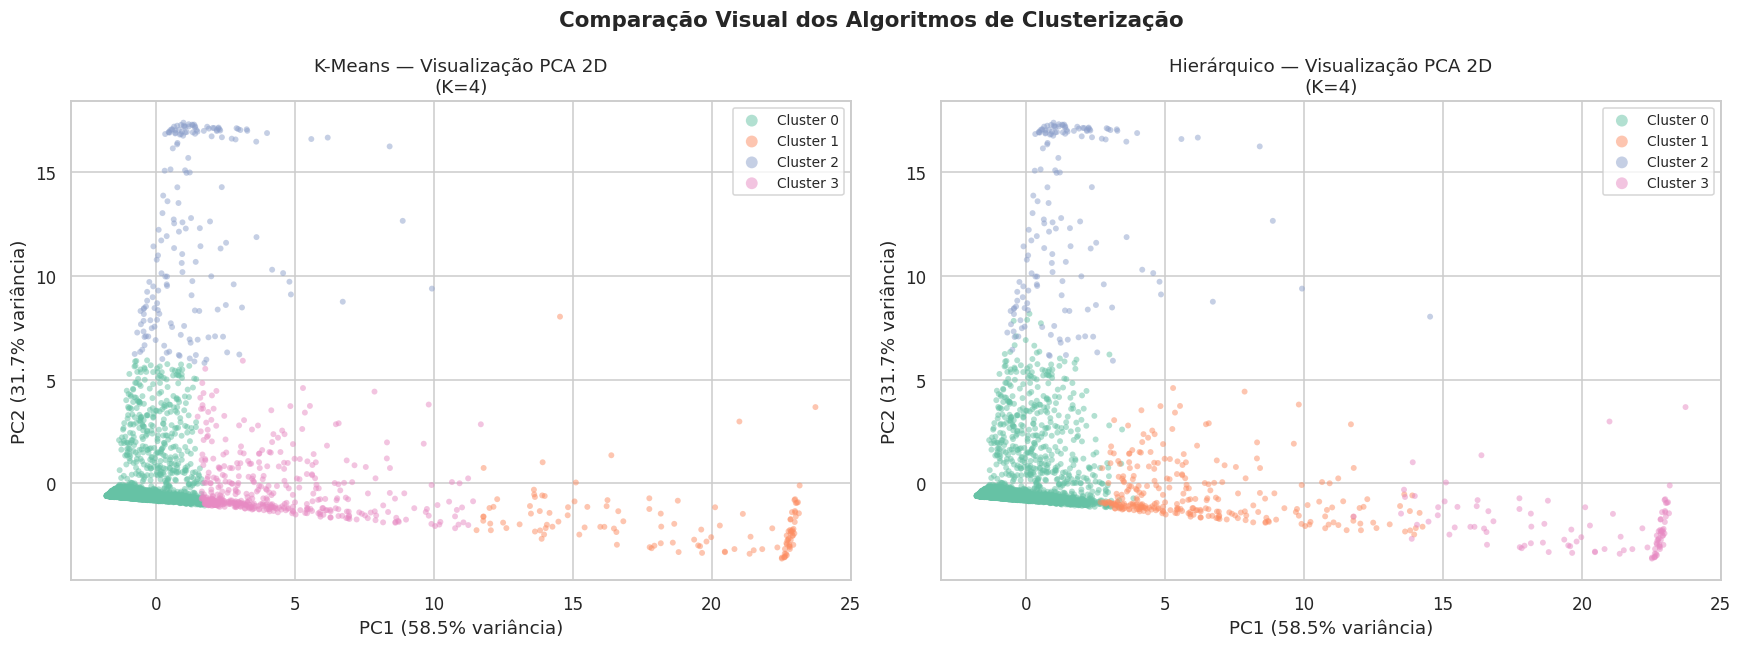

Fonte: elaborado pelos autores (2026).


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = sns.color_palette('Set2', K_FINAL)

algoritmos = [('K-Means', labels_km), ('Hierárquico', labels_agg)]

for ax, (nome, labels) in zip(axes, algoritmos):
    for cluster_id in range(K_FINAL):
        mask = labels == cluster_id
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=[palette[cluster_id]], label=f'Cluster {cluster_id}',
                   alpha=0.5, s=15, edgecolors='none')
    ax.set_title(f'{nome} — Visualização PCA 2D\n(K={K_FINAL})', fontsize=12)
    ax.set_xlabel(f'PC1 ({var_exp[0]:.1%} variância)')
    ax.set_ylabel(f'PC2 ({var_exp[1]:.1%} variância)')
    ax.legend(markerscale=2, fontsize=9)

plt.suptitle('Comparação Visual dos Algoritmos de Clusterização', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_clusters_pca.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

### 4.2 Perfil Médio dos Clusters (K-Means)

Análise das características médias de cada cluster para interpretação do perfil turístico.

📊 Perfil Médio por Cluster (K-Means):


,gdp_capita,idhm,leitos_1000hab,hoteis_1000hab,servicos_1000hab,agencias_total,uber,estimated_pop,n_cidades
cluster_kmeans,,,,,,,,,
0,19192.85,0.65,0.23,0.01,0.91,1.24,0.00,14131.67,4835
1,35978.70,0.76,1.11,0.01,2.01,30.03,0.59,353713.07,128
2,27333.73,0.68,12.90,0.22,2.80,2.39,0.01,23730.72,173
3,28336.79,0.72,0.95,0.01,1.72,7.73,0.11,104169.14,428


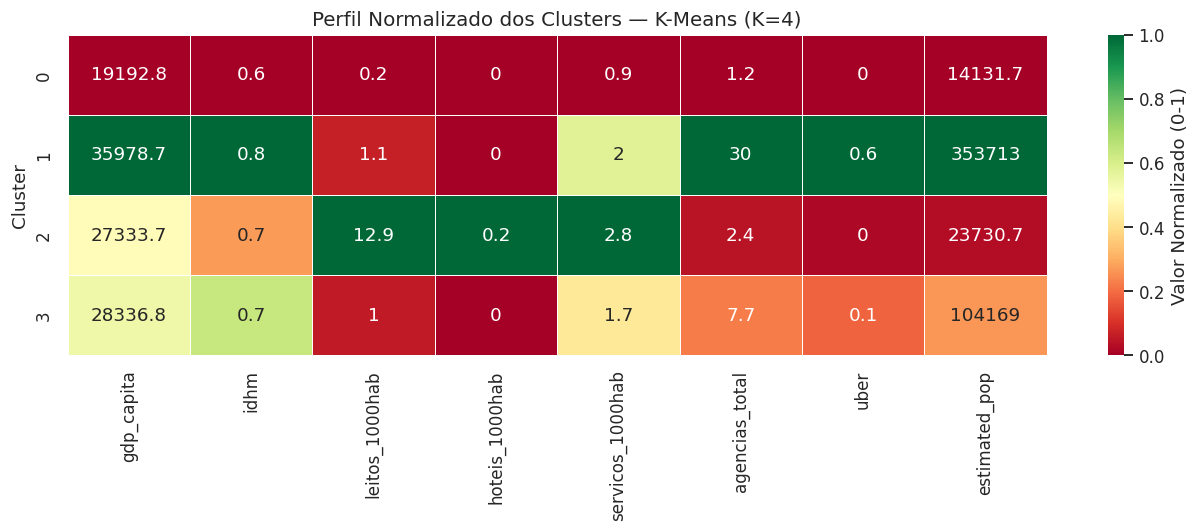

Fonte: elaborado pelos autores (2026).


In [ ]:
df_resultado = df_proc[['city', 'state', 'macrorregiao'] + FEATURES +
                        ['potencial_joia_escondida', 'quadrante_dashboard']].copy()
df_resultado['cluster_kmeans'] = labels_km

# Perfil médio por cluster
perfil = df_resultado.groupby('cluster_kmeans')[FEATURES].mean().round(2)
perfil['n_cidades'] = df_resultado['cluster_kmeans'].value_counts().sort_index()

print('📊 Perfil Médio por Cluster (K-Means):')
display(perfil)

# Heatmap do perfil normalizado
perfil_norm = (perfil[FEATURES] - perfil[FEATURES].min()) / (perfil[FEATURES].max() - perfil[FEATURES].min())

plt.figure(figsize=(12, 5))
sns.heatmap(perfil_norm, annot=perfil[FEATURES].round(1), fmt='g',
            cmap='RdYlGn', linewidths=0.5, cbar_kws={'label': 'Valor Normalizado (0-1)'})
plt.title(f'Perfil Normalizado dos Clusters — K-Means (K={K_FINAL})', fontsize=13)
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('fig_perfil_clusters.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

### 4.3 Boxplots das Features por Cluster


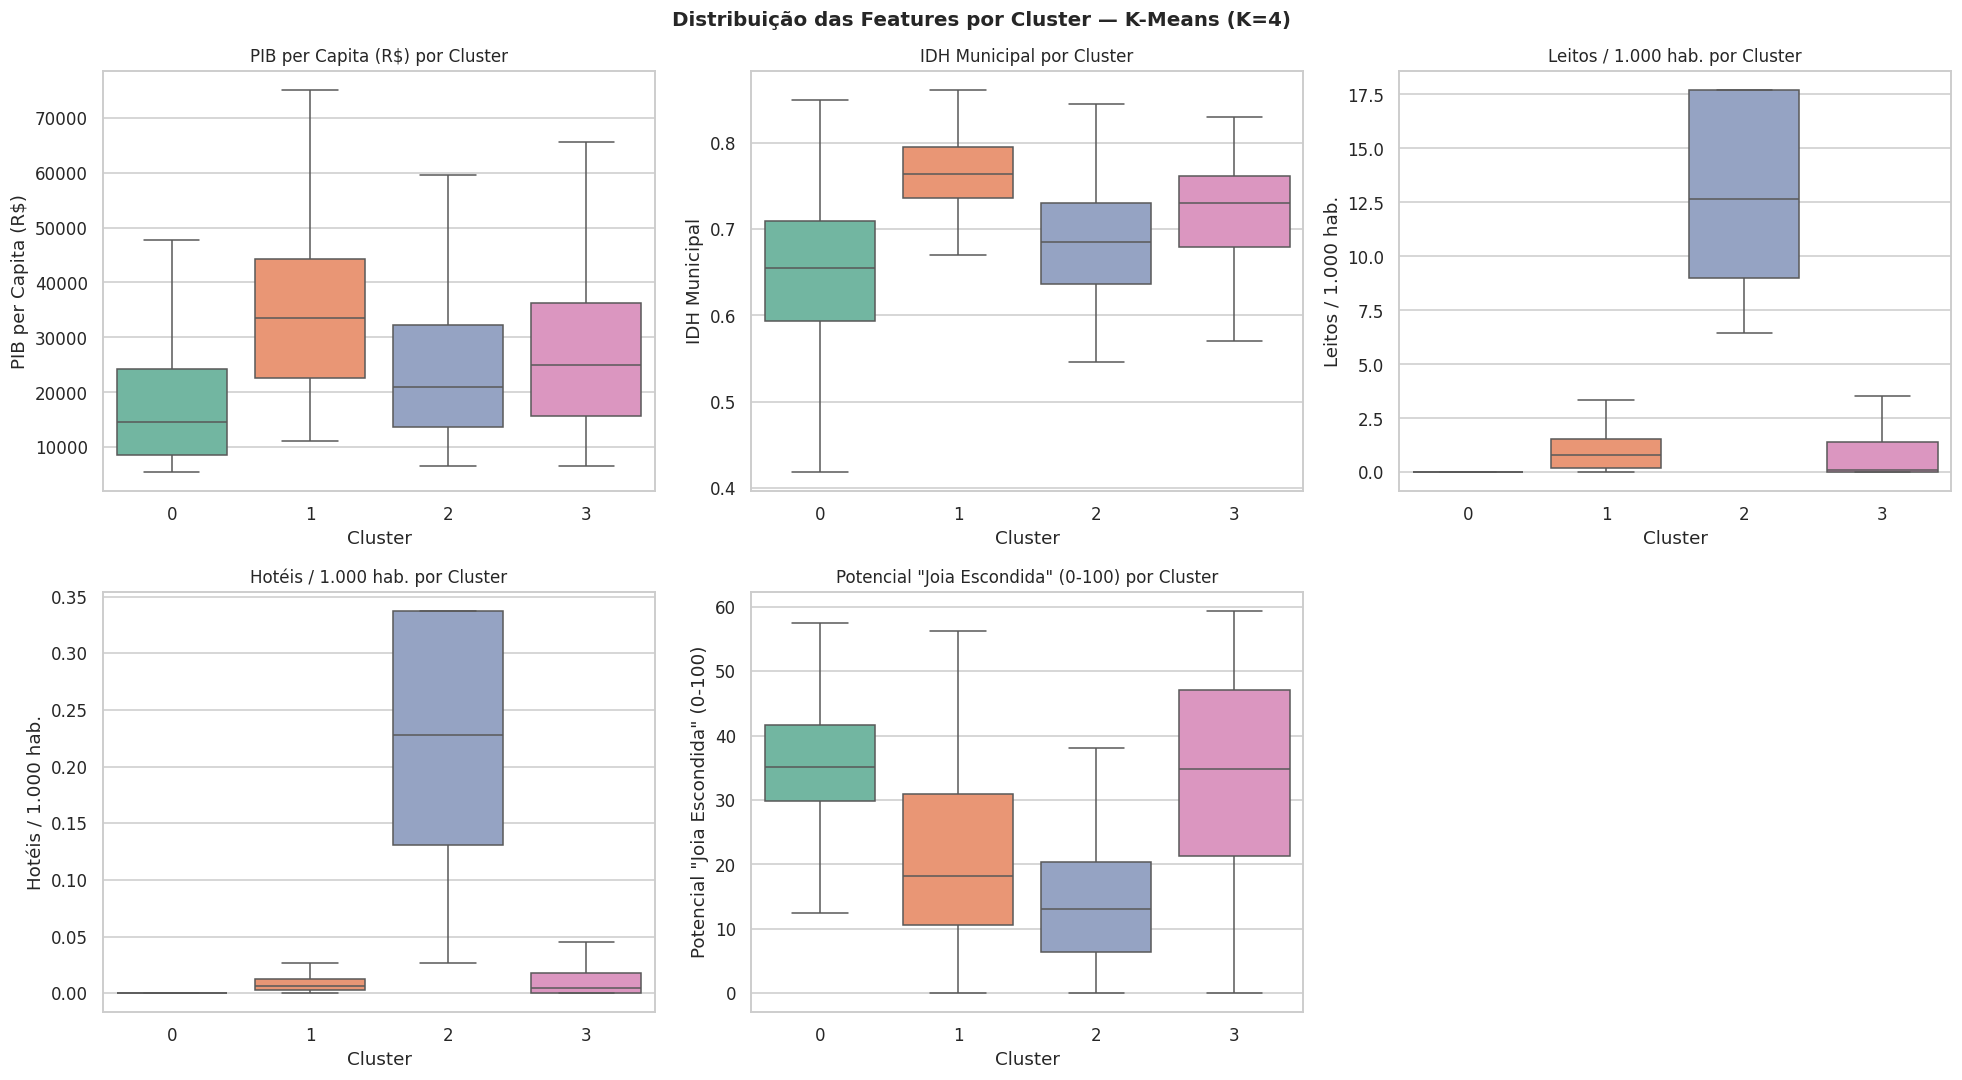

Fonte: elaborado pelos autores (2026).


In [ ]:
FEATURES_PLOT = ['gdp_capita', 'idhm', 'leitos_1000hab', 'hoteis_1000hab', 'potencial_joia_escondida']
LABELS_PLOT   = ['PIB per Capita (R$)', 'IDH Municipal', 'Leitos / 1.000 hab.',
                 'Hotéis / 1.000 hab.', 'Potencial "Joia Escondida" (0-100)']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, feat, label in zip(axes, FEATURES_PLOT, LABELS_PLOT):
    sns.boxplot(data=df_resultado, x='cluster_kmeans', y=feat,
                palette='Set2', ax=ax, showfliers=False)
    ax.set_title(f'{label} por Cluster', fontsize=11)
    ax.set_xlabel('Cluster')
    ax.set_ylabel(label)

axes[-1].axis('off')  # grade 2x3, 5 gráficos

plt.suptitle(f'Distribuição das Features por Cluster — K-Means (K={K_FINAL})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_boxplot_clusters.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

---
## 🔍 Fase 5 — Interpretação dos Clusters e Identificação das Joias Escondidas

### 5.1 Nomeação dos Clusters

Com base no perfil médio de cada cluster, atribuímos rótulos interpretáveis. **Ajuste os nomes abaixo após analisar os gráficos da Fase 4.**

In [ ]:
# ── Nomeação dinâmica dos clusters, alinhada ao vocabulário do Dashboard ──
perfil_full = df_resultado.groupby('cluster_kmeans')[
    FEATURES + ['potencial_joia_escondida']
].mean()

clusters_disponiveis = list(perfil_full.index)
NOMES_CLUSTERS = {}

# 1) Polos Urbanos Consolidados → maior população média
c_urbano = perfil_full['estimated_pop'].idxmax()
NOMES_CLUSTERS[c_urbano] = 'Polos Urbanos Consolidados'
clusters_disponiveis.remove(c_urbano)

# 2) Destinos com Conversão Turística Alta → maior infraestrutura hoteleira
infra_score = perfil_full.loc[clusters_disponiveis, ['leitos_1000hab','hoteis_1000hab']].sum(axis=1)
c_conversao = infra_score.idxmax()
NOMES_CLUSTERS[c_conversao] = 'Destinos com Conversão Turística Alta'
clusters_disponiveis.remove(c_conversao)

# 3) Potencial Não Convertido / Joias Potenciais → maior potencial_joia_escondida
c_joia = perfil_full.loc[clusters_disponiveis, 'potencial_joia_escondida'].idxmax()
NOMES_CLUSTERS[c_joia] = 'Potencial Não Convertido / Joias Potenciais'
clusters_disponiveis.remove(c_joia)

# 4) cluster restante → Baixa Estrutura Turística
for c in clusters_disponiveis:
    NOMES_CLUSTERS[c] = 'Municípios com Baixa Estrutura Turística'

df_resultado['perfil_turistico'] = df_resultado['cluster_kmeans'].map(NOMES_CLUSTERS)

print('✅ Clusters nomeados (vocabulário alinhado ao Dashboard Brasil em Foco):')
for cid, nome in sorted(NOMES_CLUSTERS.items()):
    print(f'   Cluster {cid} → {nome}')
print()
print(df_resultado['perfil_turistico'].value_counts())

✅ Clusters nomeados (vocabulário alinhado ao Dashboard Brasil em Foco):
   Cluster 0 → Potencial Não Convertido / Joias Potenciais
   Cluster 1 → Polos Urbanos Consolidados
   Cluster 2 → Destinos com Conversão Turística Alta
   Cluster 3 → Municípios com Baixa Estrutura Turística

perfil_turistico
Potencial Não Convertido / Joias Potenciais    4835
Municípios com Baixa Estrutura Turística        428
Destinos com Conversão Turística Alta           173
Polos Urbanos Consolidados                      128
Name: count, dtype: int64


### 5.2 Identificação das Joias Escondidas

In [ ]:
mediana_idhm   = df_resultado['idhm'].median()
mediana_leitos = df_resultado['leitos_1000hab'].median()

# Critério CANÔNICO (mesmo do Dashboard e da EDA)
joias = df_resultado[
    df_resultado['quadrante_dashboard'] == 'Alto IDH + Estrutura Limitada'
].copy()

print(f'💎 Joias Escondidas identificadas (critério canônico do Dashboard): {len(joias)} municípios')
print(f'\n   Distribuição por cluster:')
print(joias['perfil_turistico'].value_counts())

print('\n🏆 Top 15 Joias Escondidas por Potencial (Dashboard):')
display(
    joias[['city', 'state', 'idhm', 'gdp_capita', 'leitos_1000hab',
           'potencial_joia_escondida', 'perfil_turistico']]
    .sort_values('potencial_joia_escondida', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

💎 Joias Escondidas identificadas (critério canônico do Dashboard): 1377 municípios

   Distribuição por cluster:
perfil_turistico
Potencial Não Convertido / Joias Potenciais    1187
Municípios com Baixa Estrutura Turística        159
Polos Urbanos Consolidados                       27
Destinos com Conversão Turística Alta             4
Name: count, dtype: int64

🏆 Top 15 Joias Escondidas por Potencial (Dashboard):


,city,state,idhm,gdp_capita,leitos_1000hab,potencial_joia_escondida,perfil_turistico
0,Sant'Ana Do Livramento,RS,0.727,27878.48,0.0,59.4,Municípios com Baixa Estrutura Turística
1,Itumbiara,GO,0.752,40477.15,0.0,59.1,Municípios com Baixa Estrutura Turística
2,AvarÃ©,SP,0.767,28025.47,0.0,58.4,Municípios com Baixa Estrutura Turística
3,Atibaia,SP,0.765,42412.58,0.0,58.2,Municípios com Baixa Estrutura Turística
4,SÃ£o Vicente,SP,0.768,14096.68,0.0,56.3,Polos Urbanos Consolidados
5,Monte Alegre Do Sul,SP,0.759,24612.81,0.0,56.2,Potencial Não Convertido / Joias Potenciais
6,Aracaju,SE,0.770,25717.68,0.0,56.2,Polos Urbanos Consolidados
7,Holambra,SP,0.790,66380.04,0.0,55.9,Potencial Não Convertido / Joias Potenciais
8,Saquarema,RJ,0.710,26152.13,0.0,55.8,Municípios com Baixa Estrutura Turística
9,Nova Mutum,MT,0.758,71101.06,0.0,55.3,Potencial Não Convertido / Joias Potenciais


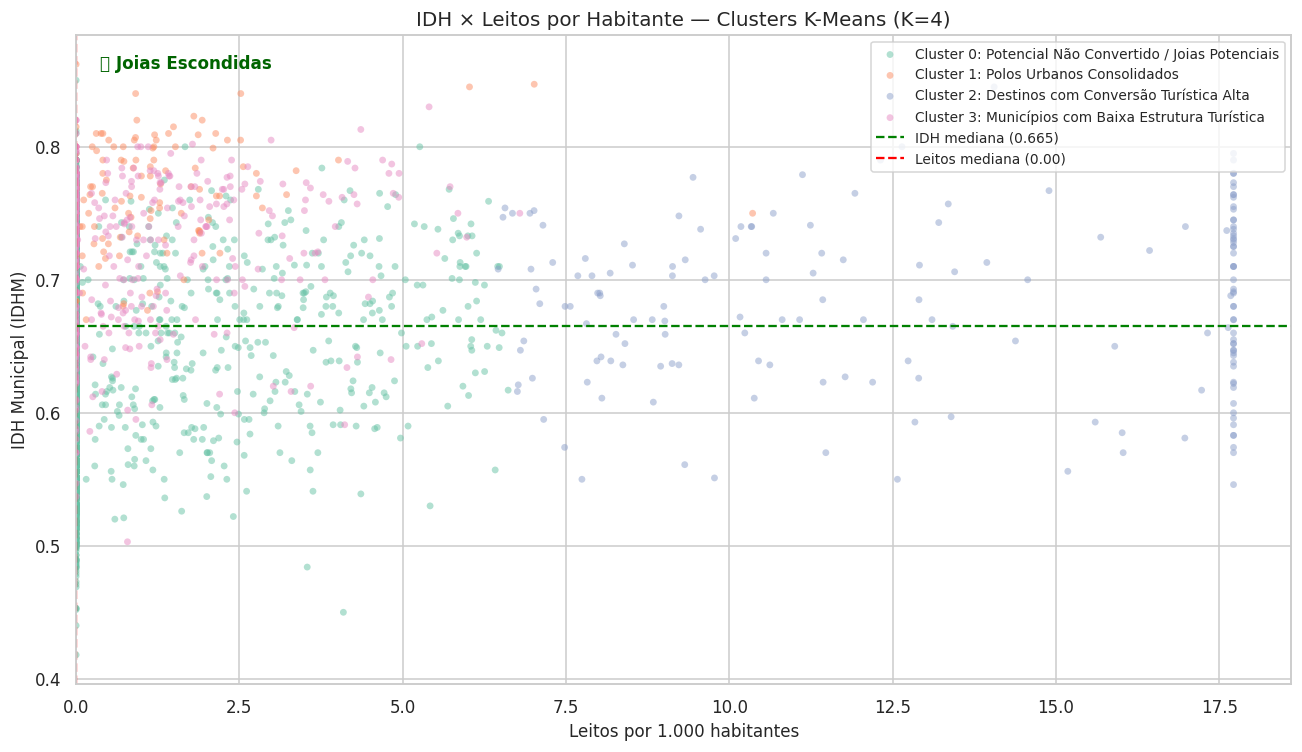

Fonte: elaborado pelos autores (2026).


In [ ]:
# Scatter IDH × Leitos colorido por cluster
fig, ax = plt.subplots(figsize=(12, 7))

palette_clusters = sns.color_palette('Set2', K_FINAL)

for cluster_id in range(K_FINAL):
    mask = df_resultado['cluster_kmeans'] == cluster_id
    nome = NOMES_CLUSTERS.get(cluster_id, f'Cluster {cluster_id}')
    ax.scatter(
        df_resultado.loc[mask, 'leitos_1000hab'],
        df_resultado.loc[mask, 'idhm'],
        c=[palette_clusters[cluster_id]],
        label=f'Cluster {cluster_id}: {nome}',
        alpha=0.5, s=20, edgecolors='none'
    )

ax.axhline(mediana_idhm, color='green', linestyle='--', linewidth=1.5,
           label=f'IDH mediana ({mediana_idhm:.3f})')
ax.axvline(mediana_leitos, color='red', linestyle='--', linewidth=1.5,
           label=f'Leitos mediana ({mediana_leitos:.2f})')

# Anotação do quadrante das joias
ax.text(0.02, 0.97, '💎 Joias Escondidas', transform=ax.transAxes,
        fontsize=11, color='darkgreen', fontweight='bold', va='top')

ax.set_xlabel('Leitos por 1.000 habitantes', fontsize=11)
ax.set_ylabel('IDH Municipal (IDHM)', fontsize=11)
ax.set_title(f'IDH × Leitos por Habitante — Clusters K-Means (K={K_FINAL})', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(left=0)
plt.tight_layout()
plt.savefig('fig_scatter_clusters_joias.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

### 5.3 Distribuição dos Clusters por Macrorregião

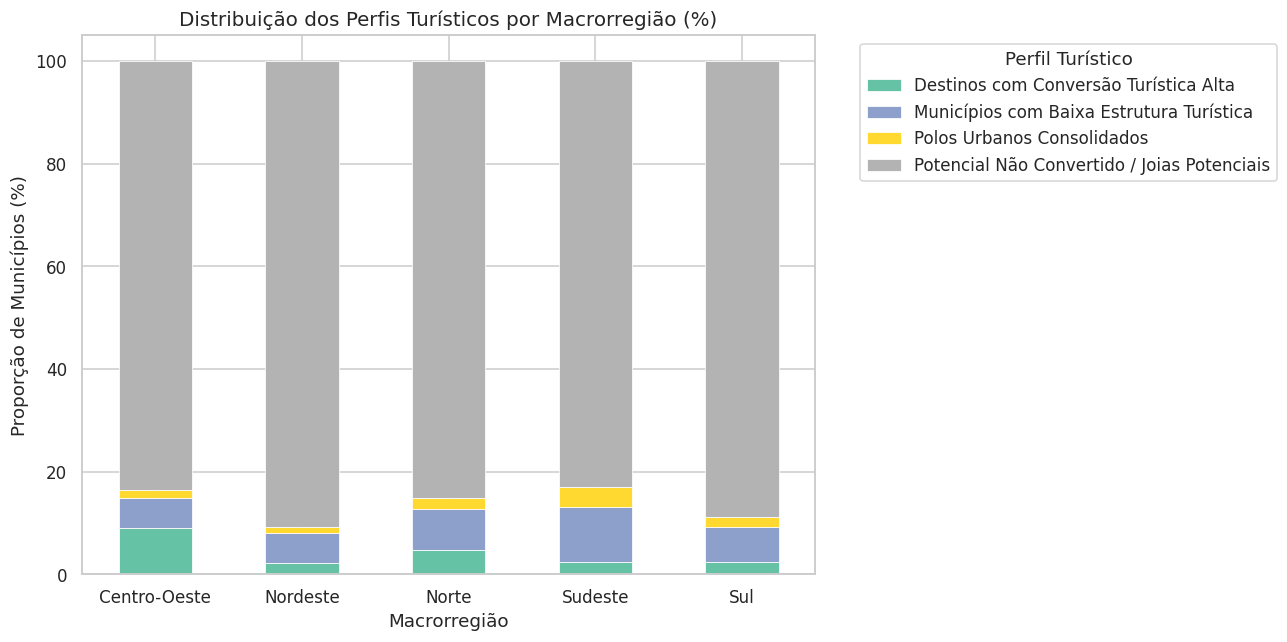

Fonte: elaborado pelos autores (2026).


In [ ]:
map_regiao = {
    'AC':'Norte','AM':'Norte','AP':'Norte','PA':'Norte','RO':'Norte','RR':'Norte','TO':'Norte',
    'AL':'Nordeste','BA':'Nordeste','CE':'Nordeste','MA':'Nordeste','PB':'Nordeste',
    'PE':'Nordeste','PI':'Nordeste','RN':'Nordeste','SE':'Nordeste',
    'DF':'Centro-Oeste','GO':'Centro-Oeste','MS':'Centro-Oeste','MT':'Centro-Oeste',
    'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
    'PR':'Sul','RS':'Sul','SC':'Sul'
}

df_resultado['macrorregiao'] = df_resultado['state'].map(map_regiao)

cross = pd.crosstab(df_resultado['macrorregiao'], df_resultado['perfil_turistico'], normalize='index') * 100

cross.plot(kind='bar', stacked=True, figsize=(12, 6),
           colormap='Set2', edgecolor='white', linewidth=0.5)
plt.title('Distribuição dos Perfis Turísticos por Macrorregião (%)', fontsize=13)
plt.xlabel('Macrorregião')
plt.ylabel('Proporção de Municípios (%)')
plt.xticks(rotation=0)
plt.legend(title='Perfil Turístico', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig_clusters_por_regiao.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

---
## 📝 Síntese dos Resultados

### Resumo da Clusterização

In [ ]:
print('='*65)
print('           SÍNTESE DA CLUSTERIZAÇÃO — BRASIL EM FOCO')
print('='*65)

print(f'\n🔵 Algoritmo selecionado: K-Means')
print(f'   Justificativa: melhor equilíbrio entre Silhueta, Davies-Bouldin')
print(f'   e Calinski-Harabász em comparação com Hierárquico e DBSCAN.\n')

print(f'🔵 Número de clusters: K={K_FINAL}')
print(f'   Embora K={best_k_silhouette} tenha apresentado a maior silhueta,')
print(f'   K=4 foi escolhido por oferecer melhor capacidade interpretativa')
print(f'   para o problema turístico. O método do cotovelo indica redução')
print(f'   relevante da inércia até aproximadamente quatro grupos, e essa')
print(f'   escolha permite diferenciar perfis mais úteis para a análise do dashboard.\n')

print(f'🔵 Métricas finais (K-Means):')
print(f'   Silhueta:          {sil_km:.4f}')
print(f'   Davies-Bouldin:    {db_km:.4f}')
print(f'   Calinski-Harabász: {ch_km:.1f}\n')

print(f'🔵 Perfis identificados (vocabulário alinhado ao Dashboard):')
for cid, nome in sorted(NOMES_CLUSTERS.items()):
    n = (labels_km == cid).sum()
    print(f'   Cluster {cid} — {nome}: {n} municípios ({n/len(labels_km)*100:.1f}%)')

print(f'\n💎 Joias Escondidas (critério canônico do Dashboard): {len(joias)} municípios')
print(f'   Critério: quadrante_dashboard == "Alto IDH + Estrutura Limitada"')
print(f'   (mesma fórmula de potencial_joia_escondida usada na EDA e no app)\n')
print(f'   Distribuição das joias entre os clusters:')
for nome, n in joias['perfil_turistico'].value_counts().items():
    print(f'     • {nome}: {n}')
print('='*65)
print('# Insight para o sistema:')
print('# A clusterização confirma a hipótese central do Brasil em Foco usando')
print('# EXATAMENTE a mesma métrica de potencial_joia_escondida do Dashboard:')
print('# existem cidades com alto IDH e baixa oferta turística —')
print('# destinos com potencial real ainda não explorado pelo turismo formal.')

           SÍNTESE DA CLUSTERIZAÇÃO — BRASIL EM FOCO

🔵 Algoritmo selecionado: K-Means
   Justificativa: melhor equilíbrio entre Silhueta, Davies-Bouldin
   e Calinski-Harabász em comparação com Hierárquico e DBSCAN.

🔵 Número de clusters: K=4
   Embora K=2 tenha apresentado a maior silhueta,
   K=4 foi escolhido por oferecer melhor capacidade interpretativa
   para o problema turístico. O método do cotovelo indica redução
   relevante da inércia até aproximadamente quatro grupos, e essa
   escolha permite diferenciar perfis mais úteis para a análise do dashboard.

🔵 Métricas finais (K-Means):
   Silhueta:          0.5969
   Davies-Bouldin:    0.7051
   Calinski-Harabász: 5796.2

🔵 Perfis identificados (vocabulário alinhado ao Dashboard):
   Cluster 0 — Potencial Não Convertido / Joias Potenciais: 4835 municípios (86.9%)
   Cluster 1 — Polos Urbanos Consolidados: 128 municípios (2.3%)
   Cluster 2 — Destinos com Conversão Turística Alta: 173 municípios (3.1%)
   Cluster 3 — Municípios 

---
## 💾 Exportação dos Resultados

In [ ]:
df_export = df_resultado[['city', 'state', 'macrorregiao'] + FEATURES +
                          ['potencial_joia_escondida', 'quadrante_dashboard',
                           'cluster_kmeans', 'perfil_turistico']].copy()

df_export.to_csv('cities_clustered.csv', index=False, encoding='utf-8')
print('✅ Dataset com clusters exportado: cities_clustered.csv')
print(f'   Shape: {df_export.shape}')
print(f'\n📁 Figuras geradas:')
figuras = [
    'fig_winsorization.png',
    'fig_pca_variance.png',
    'fig_cotovelo_silhueta.png',
    'fig_silhueta_detalhada.png',
    'fig_clusters_pca.png',
    'fig_perfil_clusters.png',
    'fig_boxplot_clusters.png',
    'fig_scatter_clusters_joias.png',
    'fig_clusters_por_regiao.png'
]
for f in figuras:
    print(f'   📊 {f}')

✅ Dataset com clusters exportado: cities_clustered.csv
   Shape: (5564, 15)

📁 Figuras geradas:
   📊 fig_winsorization.png
   📊 fig_pca_variance.png
   📊 fig_cotovelo_silhueta.png
   📊 fig_silhueta_detalhada.png
   📊 fig_clusters_pca.png
   📊 fig_perfil_clusters.png
   📊 fig_boxplot_clusters.png
   📊 fig_scatter_clusters_joias.png
   📊 fig_clusters_por_regiao.png
